<a href="https://colab.research.google.com/github/thinothw/DFDS-Final-Project/blob/main/Phase_02_Sandbox_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01 - Environment Setup.

In [1]:
import os
import shutil
import time
from google.colab import drive
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt

print("Connecting to Google Drive Vault.")
drive.mount('/content/drive')
print("Environment initialized.")

Connecting to Google Drive Vault.
Mounted at /content/drive
Environment initialized.


02 - Dataset Funnel.

In [2]:
# SSD Teleportation and The PyTorch Funnel.
import os
import shutil
import zipfile
import random
import numpy as np
import time
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset

print("Initiating Data Teleportation and Virtual Merge...\n")

# Deterministic Reproducibility.
print("Locking down global seeds for 100% reproducibility...")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ROBUST COPY WRAPPER (Anti FUSE Crash)
def robust_copy(src, dst, max_retries=5, delay=5):
    for attempt in range(max_retries):
        try:
            shutil.copy2(src, dst)
            return True
        except OSError as e:
            print(f"WARNING: FUSE Drop Detected (Attempt {attempt + 1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                print(f"Retrying in {delay} seconds...")
                time.sleep(delay)
            else:
                raise RuntimeError(f"CRITICAL: Google Drive FUSE connection permanently severed for {src}.")

# PATHS
drive_base = '/content/drive/MyDrive/Deepfake_Honours_Project/Sandbox_10K'
datasets_to_load = {
    'Celeb_DF': os.path.join(drive_base, 'Celeb_DF_Sandbox', 'processed_faces.zip'),
    'FFplusplus': os.path.join(drive_base, 'FF_Plus', 'processed_faces.zip'),
    'OpenFake': os.path.join(drive_base, 'OpenFake', 'processed_faces.zip')
}

local_base = '/content/dataset'
shutil.rmtree(local_base, ignore_errors=True)
os.makedirs(local_base, exist_ok=True)

# ZIP VERIFICATION AND SSD TELEPORTATION
for name, zip_path in datasets_to_load.items():
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"CRITICAL: Cannot find {zip_path}")

    # The Zip Peek - Verify structure before unpacking
    with zipfile.ZipFile(zip_path, 'r') as z:
        top_level_items = set(item.split('/')[0] for item in z.namelist())
        if 'train' not in top_level_items:
            raise ValueError(f"CRITICAL: {name} zip is wrapped incorrectly. Found: {top_level_items}")

    print(f"Teleporting {name} to local SSD...")
    local_zip = os.path.join(local_base, f"{name}.zip")
    extract_dir = os.path.join(local_base, name)

    robust_copy(zip_path, local_zip)
    shutil.unpack_archive(local_zip, extract_dir)
    os.remove(local_zip)
    print(f"Secured {name} at {extract_dir}")

# SPLIT TRANSFORMS
train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# THE VIRTUAL MERGE AND SAFETY CHECKS
print("\nStitching datasets and normalizing labels...")

train_datasets, val_datasets, test_datasets = [], [], []

def get_binary_label(path):
    # Logic to force any folder with 'fake' in name to 0, and 'real' to 1.
    folder_name = os.path.basename(os.path.dirname(path)).lower()
    if 'fake' in folder_name:
        return 0
    elif 'real' in folder_name:
        return 1
    else:
        raise ValueError(f"Unknown folder name: {folder_name}")

class BinaryImageFolder(datasets.ImageFolder):
    # Custom loader that overrides the default label assignment.
    def __getitem__(self, index):
        path, _ = self.samples[index]
        target = get_binary_label(path)
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

for name in datasets_to_load.keys():
    ds_path = os.path.join(local_base, name)

    # Apply the custom binary loader to each split
    tr = BinaryImageFolder(os.path.join(ds_path, 'train'), transform=train_transform)
    vl = BinaryImageFolder(os.path.join(ds_path, 'val'), transform=val_test_transform)
    ts = BinaryImageFolder(os.path.join(ds_path, 'test'), transform=val_test_transform)

    train_datasets.append(tr)
    val_datasets.append(vl)
    test_datasets.append(ts)
    print(f"Normalized and Loaded: {name}")

master_train = ConcatDataset(train_datasets)
master_val = ConcatDataset(val_datasets)
master_test = ConcatDataset(test_datasets)

print(f"\nTotal Train Images: {len(master_train)}")
print(f"Total Val Images: {len(master_val)}")
print(f"Total Test Images: {len(master_test)}")

# DETERMINISTIC DATALOADERS
BATCH_SIZE = 32
generator = torch.Generator()
generator.manual_seed(seed)

train_loader = DataLoader(master_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True, generator=generator)
val_loader = DataLoader(master_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(master_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nThe Funnel is Locked In.")

Initiating Data Teleportation and Virtual Merge...

Locking down global seeds for 100% reproducibility...
Teleporting Celeb_DF to local SSD...
Secured Celeb_DF at /content/dataset/Celeb_DF
Teleporting FFplusplus to local SSD...
Secured FFplusplus at /content/dataset/FFplusplus
Teleporting OpenFake to local SSD...
Secured OpenFake at /content/dataset/OpenFake

Stitching datasets and normalizing labels...
Normalized and Loaded: Celeb_DF
Normalized and Loaded: FFplusplus
Normalized and Loaded: OpenFake

Total Train Images: 7000
Total Val Images: 1493
Total Test Images: 1502

The Funnel is Locked In.


03 - EfficientNet-B2 Architecture.

In [3]:
import torch
import torch.nn as nn
from torchvision import models

print("Downloading pre trained EfficientNet-B2 Base...")
# Fetching the most up-to-date ImageNet weights
weights = models.EfficientNet_B2_Weights.DEFAULT
model = models.efficientnet_b2(weights=weights)

print("Freezing base layers to retain generalized feature extraction...")
for param in model.parameters():
    param.requires_grad = False

print("Attaching custom Deepfake Classification Head...")
# Extract the input size of the original classifier (1408 for B2)
in_features = model.classifier[1].in_features

# Replace the 1000 class head with a 2 class head (0=Fake, 1=Real)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, 2)
)

# Mount the architecture to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model successfully mounted to {device.type.upper()}.")

# SANITY CHECK
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} (Classification Head Only)\n")

# OPTIMIZER AND LOSS
# Added weight_decay (L2 regularization) to prevent minor overfitting
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

print("The Brain is assembled. Ready for the training loop.")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 106MB/s]


Freezing base layers to retain generalized feature extraction...
Attaching custom Deepfake Classification Head...
Model successfully mounted to CUDA.

Total Parameters: 7,703,812
Trainable Parameters: 2,818 (Classification Head Only)

The Brain is assembled. Ready for the training loop.


* WandB Setup.


In [4]:
# SETUP CELL - SECURE
!pip install wandb -q
import wandb
from google.colab import userdata

print("Authenticating with Weights & Biases...")

try:
    # Pull the API key from the Colab Secrets Vault
    wandb_key = userdata.get('WANDB_API_KEY')

    # Login silently
    wandb.login(key=wandb_key)
    print("WandB login successful. Telemetry secured.")
except Exception as e:
    print("CRITICAL: Failed to load WANDB_API_KEY from Colab Secrets.")
    print(f"Error details: {e}")

Authenticating with Weights & Biases...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: thinothwickramasinghe (thinothwickramasinghe-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB login successful. Telemetry secured.


04 - The Training Loop and Research Graphs. Train / Val.


Phase 2: Initializing Production-Grade Fine-Tuning...

Unfreezing EfficientNet-B2 base layers...


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Starting Fine-Tuning Loop for 10 Epochs...

Epoch [1/10] | LR: 1.0e-05 | Train Loss: 0.6610 | Val Loss: 0.6151 | Val Acc: 0.7019 | Val F1: 0.7007 | Val AUC: 0.7696
Epoch [2/10] | LR: 1.0e-05 | Train Loss: 0.5542 | Val Loss: 0.5257 | Val Acc: 0.7428 | Val F1: 0.7359 | Val AUC: 0.8311
Epoch [3/10] | LR: 1.0e-05 | Train Loss: 0.4636 | Val Loss: 0.4561 | Val Acc: 0.7783 | Val F1: 0.7815 | Val AUC: 0.8720
Epoch [4/10] | LR: 1.0e-05 | Train Loss: 0.3788 | Val Loss: 0.3981 | Val Acc: 0.8165 | Val F1: 0.8209 | Val AUC: 0.9027
Epoch [5/10] | LR: 1.0e-05 | Train Loss: 0.3251 | Val Loss: 0.3724 | Val Acc: 0.8346 | Val F1: 0.8341 | Val AUC: 0.9135
Epoch [6/10] | LR: 1.0e-05 | Train Loss: 0.2751 | Val Loss: 0.3530 | Val Acc: 0.8392 | Val F1: 0.8349 | Val AUC: 0.9239
Epoch [7/10] | LR: 1.0e-05 | Train Loss: 0.2445 | Val Loss: 0.3406 | Val Acc: 0.8459 | Val F1: 0.8497 | Val AUC: 0.9304
Epoch [8/10] | LR: 1.0e-05 | Train Loss: 0.2175 | Val Loss: 0.3127 | Val Acc: 0.8674 | Val F1: 0.8653 | Val AUC: 0.9

epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▃▂▂▂▁▁
val_acc,▁▃▄▆▆▇▇███
val_auc,▁▃▅▆▇▇▇███
val_f1,▁▂▄▆▆▆▇███
val_loss,█▆▄▃▃▂▂▁▁▁
epoch,10
learning_rate,1e-05
train_loss,0.17108
val_acc,0.87207



Generating visual assets...


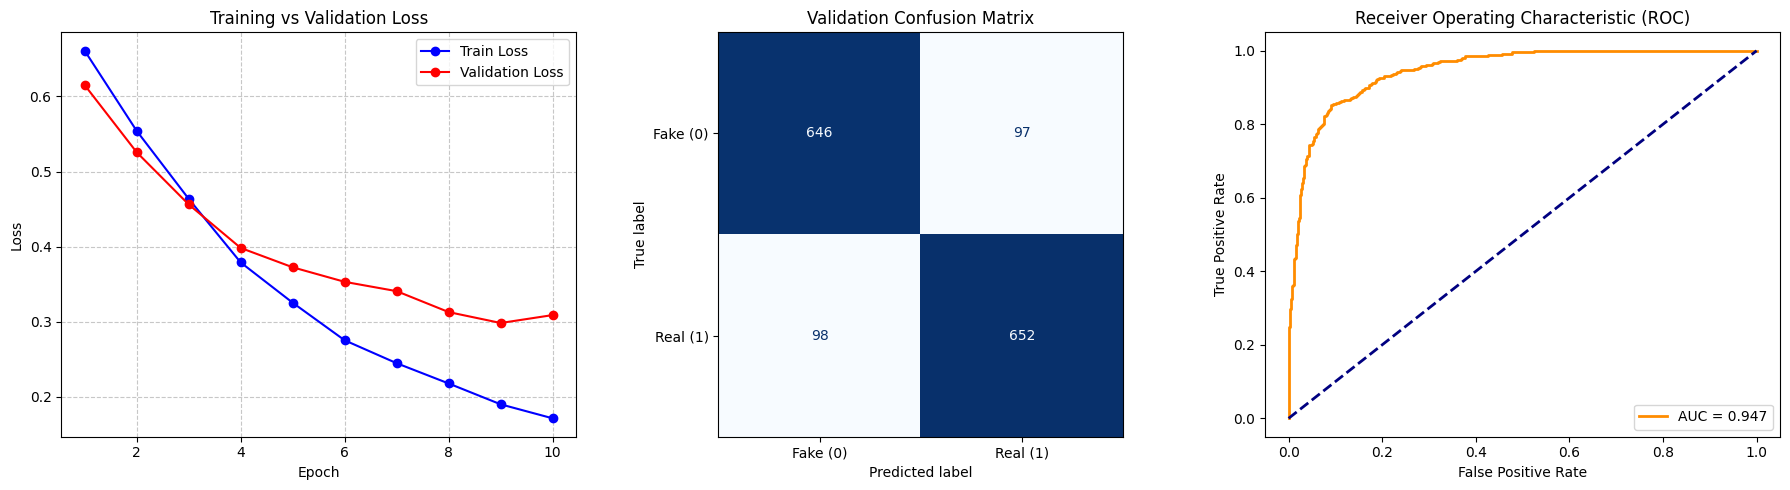

In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
import wandb
import os

EPOCHS = 10
best_val_loss = float('inf')
checkpoint_path = '/content/best_b2_sandbox_finetuned.pth'

print("Phase 2: Initializing Production-Grade Fine-Tuning...\n")

try:
    wandb.finish()
except:
    pass

print("Unfreezing EfficientNet-B2 base layers...")
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2,)

wandb.init(
    project="deepfake-sandbox-finetune",
    name="effnet-b2-unfrozen-final",
    reinit=True,
    config={
        "learning_rate": 1e-5,
        "epochs": EPOCHS,
        "architecture": "EfficientNet-B2 Unfrozen",
        "dataset": "Sandbox_10K"
    }
)

train_losses, val_losses = [], []
all_true_labels, all_pred_probs, all_pred_classes = [], [], []

print(f"Starting Fine-Tuning Loop for {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).view(-1).long()

        # Fix: set_to_none=True
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)

        if outputs.ndim != 2 or outputs.size(1) != 2:
            raise ValueError(f"CRITICAL: Expected train output shape [batch_size, 2], got {tuple(outputs.shape)}")

        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    epoch_true, epoch_probs, epoch_preds = [], [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).view(-1).long()

            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.size(1) != 2:
                raise ValueError(f"CRITICAL: Expected val output shape [batch_size, 2], got {tuple(outputs.shape)}")

            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)

            probs = F.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            epoch_true.extend(labels.cpu().numpy().tolist())
            epoch_probs.extend(probs.cpu().numpy().tolist())
            epoch_preds.extend(preds.cpu().numpy().tolist())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    val_acc = accuracy_score(epoch_true, epoch_preds)
    val_f1 = f1_score(epoch_true, epoch_preds, zero_division=0)

    has_two_classes = len(set(epoch_true)) > 1
    val_auc = roc_auc_score(epoch_true, epoch_probs) if has_two_classes else None

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)

    auc_str = f"{val_auc:.4f}" if val_auc is not None else "NaN"
    print(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr:.1e} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Val AUC: {auc_str}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_auc": val_auc if val_auc is not None else np.nan,
        "learning_rate": current_lr
    })

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss

        # Fix: Saving extra metrics to the dictionary
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'best_val_acc': val_acc,
            'best_val_f1': val_f1,
            'best_val_auc': val_auc if val_auc is not None else 0.5
        }
        torch.save(checkpoint, checkpoint_path)

        all_true_labels = epoch_true.copy()
        all_pred_probs = epoch_probs.copy()
        all_pred_classes = epoch_preds.copy()

print(f"\nFine-Tuning Complete. Full state checkpoint saved to '{checkpoint_path}'")
wandb.finish()

# REPORT GRAPHS
print("\nGenerating visual assets...")

has_two_classes_final = len(set(all_true_labels)) > 1
final_auc = roc_auc_score(all_true_labels, all_pred_probs) if has_two_classes_final else None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o', color='blue')
axes[0].plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='red')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

cm = confusion_matrix(all_true_labels, all_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake (0)', 'Real (1)'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Validation Confusion Matrix')

if final_auc is not None:
    fpr, tpr, _ = roc_curve(all_true_labels, all_pred_probs)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {final_auc:.3f}')
    axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].legend(loc="lower right")
else:
    axes[2].text(0.5, 0.5, 'ROC curve unavailable', ha='center', va='center')
axes[2].set_title('Receiver Operating Characteristic (ROC)')

plt.tight_layout()
plt.show()

05 - Test Run - No Training / No Weight Updates. Test.

Initiating Phase 4: Uncompromised Test Set Evaluation...

Loading optimal model weights...
Running unseen images through the EfficientNet-B2 pipeline...

FINAL TEST SET METRICS (UNSEEN DATA)
              precision    recall  f1-score   support

    Fake (0)     0.8798    0.8763    0.8781       752
    Real (1)     0.8765    0.8800    0.8782       750

    accuracy                         0.8782      1502
   macro avg     0.8782    0.8782    0.8782      1502
weighted avg     0.8782    0.8782    0.8782      1502

Absolute ROC-AUC Score: 0.9416



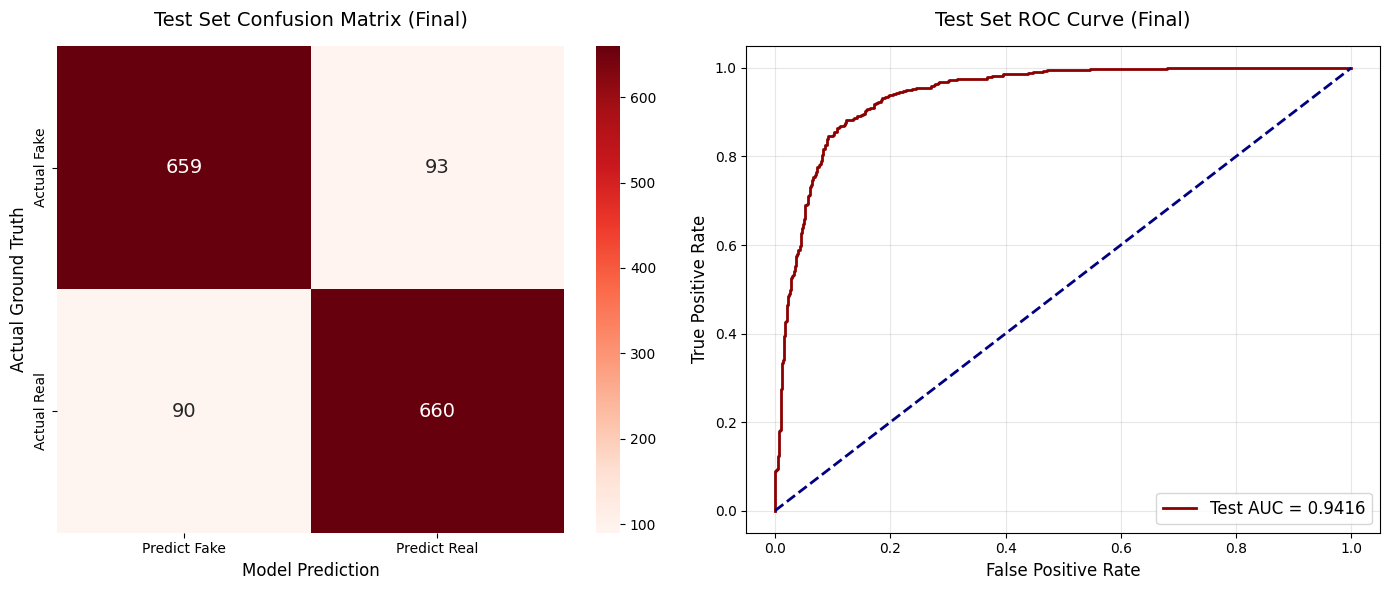

In [8]:
import torch
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Initiating Phase 4: Uncompromised Test Set Evaluation...\n")

# 1. Load the best saved weights (Updated for full State Dictionary)
weight_path = '/content/best_b2_sandbox_finetuned.pth'
if not os.path.exists(weight_path):
    raise FileNotFoundError(f"CRITICAL: Could not find {weight_path}. Did the training cell save it?")

print("Loading optimal model weights...")
checkpoint = torch.load(weight_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

test_preds = []
test_trues = []
test_probs = []

print("Running unseen images through the EfficientNet-B2 pipeline...")

# 2. Disable gradients and execute inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        # Convert labels to long - standard PyTorch practice for class indices
        labels = labels.to(device).view(-1).long()

        # Get raw logits from the 2-node head
        outputs = model(inputs)

        # DEFENSIVE TRIPWIRE: Ensure the model is actually outputting [batch_size, 2]
        if outputs.ndim != 2 or outputs.size(1) != 2:
            raise ValueError(f"CRITICAL: Expected model output shape [batch_size, 2], got {tuple(outputs.shape)}. Is the custom head missing?")

        # Convert to probabilities using Softmax.
        # [:, 1] extracts the probability specifically for Class 1 (Real) for the AUC calculation.
        probs = torch.softmax(outputs, dim=1)[:, 1]

        # Get the final prediction (0 or 1) by choosing the node with the highest probability
        preds = torch.argmax(outputs, dim=1).long()

        test_preds.extend(preds.cpu().numpy().tolist())
        test_trues.extend(labels.cpu().numpy().tolist())
        test_probs.extend(probs.cpu().numpy().tolist())

# Convert once for memory safety
test_preds = np.array(test_preds)
test_trues = np.array(test_trues)
test_probs = np.array(test_probs)

# 3. Metrics Calculation
conf_matrix = confusion_matrix(test_trues, test_preds)

has_two_classes = len(np.unique(test_trues)) == 2
if has_two_classes:
    test_auc = roc_auc_score(test_trues, test_probs)
else:
    test_auc = None

print("\n" + "="*40)
print("FINAL TEST SET METRICS (UNSEEN DATA)")
print("="*40)
print(classification_report(
    test_trues,
    test_preds,
    target_names=['Fake (0)', 'Real (1)'],
    digits=4,
    zero_division=0
))

if test_auc is not None:
    print(f"Absolute ROC-AUC Score: {test_auc:.4f}")
else:
    print("Absolute ROC-AUC Score: Undefined (test set contains only one class)")
print("="*40 + "\n")

# 4. Generate Final Report Assets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=axes[0],
    xticklabels=['Predict Fake', 'Predict Real'],
    yticklabels=['Actual Fake', 'Actual Real'],
    annot_kws={"size": 14}
)
axes[0].set_title('Test Set Confusion Matrix (Final)', fontsize=14, pad=15)
axes[0].set_xlabel('Model Prediction', fontsize=12)
axes[0].set_ylabel('Actual Ground Truth', fontsize=12)

if test_auc is not None:
    fpr, tpr, _ = roc_curve(test_trues, test_probs)
    axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Test AUC = {test_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('Test Set ROC Curve (Final)', fontsize=14, pad=15)
    axes[1].legend(loc="lower right", fontsize=12)
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'ROC curve unavailable\n(only one class in test set)',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Test Set ROC Curve (Final)', fontsize=14, pad=15)
    axes[1].axis('off')

plt.tight_layout()
plt.show()